In [2]:
pip install langchain langchain-community langchain-groq langgraph chromadb sentence-transformers requests PyPDF2 tiktoken

   ---------------------------------------- 0.0/542.4 kB ? eta -:--:--
   ---------------------------------------- 542.4/542.4 kB 7.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 20.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 25.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 20.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 25.5 MB/s  0:00:00
   ---------------------------------------- 0.0/23.4 MB ? eta -:--:--
   --------------- ------------------------ 9.2/23.4 MB 46.0 MB/s eta 0:00:01
   -------------------- ------------------- 11.8/23.4 MB 30.9 MB/s eta 0:00:01
   --------------------- ------------------ 12.6/23.4

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\tanvi\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\langchain_classic\\llms\\human.py'
Consider using the `--user` option or check the permissions.



  Using cached langchain-1.2.15-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langgraph-1.1.9-py3-none-any.whl.metadata (8.0 kB)
  Using cached chromadb-1.5.8-cp39-abi3-win_amd64.whl.metadata (5.1 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached langgraph_prebuilt-1.0.11-py3-none-any.whl.metadata (5.2 kB)
  Using cached langchain_classic-1.0.4-py3-none-any.whl.metadata (4.8 kB)
Using cached langchain-1.2.15-py3-none-any.whl (112 kB)
Using cached langgraph-1.1.9-py3-none-any.whl (173 kB)
Using cached langgraph_prebuilt-1.0.11-py3-none-any.whl (36 kB)
Using cached langchain_community-0.4.1-py3-none-any.whl (2.5 MB)
Using cached langchain_classic-1.0.4-py3-none-any.whl (1.0 MB)
Using cached chromadb-1.5.8-cp39-abi3-win_amd64.whl (23.4 MB)
Using cached sentence_transformers-5.4.1-py3-none-any.whl (571 kB)

   ---------------------------------------- 0/7 [langgraph-

In [1]:
pip install wikipedia-api

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── standard libraries ──
import os
import requests

# ── PDF reading ──
from PyPDF2 import PdfReader

# ── embeddings (runs locally, no API needed) ──
from sentence_transformers import SentenceTransformer

# ── vector store ──
import chromadb

# ── LangChain components ──
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq

# ── LangGraph ──
from langgraph.graph import StateGraph, END
from typing import TypedDict

print("All imports successful!")

c:\Users\tanvi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


In [ ]:

os.environ["GROQ_API_KEY"] = "your key"

 

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

print("LLM ready!")

LLM ready!


In [3]:
import wikipediaapi

# ── set up Wikipedia API ──
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='TwoAgentRAG/1.0 (research demo)'
)
chroma_client = chromadb.Client()
collection = chroma_client.create_collection("vtwo")
# ── articles to load ──
article_names = [
    "Albert Einstein",
    "Marie Curie",
    "Alan Turing",
    "Isaac Newton",
    "Stephen Hawking"
]
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedding model loaded!")
# ── fetch and index each article ──
all_chunks = []
all_ids = []
chunk_counter = 0
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,    # each chunk is ~500 characters
    chunk_overlap=50   # chunks overlap a little so we don't lose context at edges
)
for name in article_names:
    print(f"Fetching Wikipedia article: {name}...")
    page = wiki.page(name)
    
    if not page.exists():
        print(f"  → Article not found, skipping")
        continue
    
    # get full article text
    text = page.text
    
    # chunk it
    chunks = splitter.split_text(text)
    
    for chunk in chunks:
        all_chunks.append(chunk)
        all_ids.append(f"chunk_{chunk_counter}")
        chunk_counter += 1
    
    print(f"  → {len(chunks)} chunks created from '{name}'")

# ── embed and store in ChromaDB ──
# reset collection first in case you're re-running
try:
    chroma_client.delete_collection("research_papers")
except:
    pass

collection = chroma_client.create_collection("research_papers")

print(f"\nEmbedding {len(all_chunks)} chunks (takes 1-2 mins)...")
embeddings = embedder.encode(all_chunks).tolist()
collection.add(
    documents=all_chunks,
    embeddings=embeddings,
    ids=all_ids
)

print(f"\nDone! {len(all_chunks)} chunks indexed from {len(article_names)} Wikipedia articles.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1263.17it/s]


Embedding model loaded!
Fetching Wikipedia article: Albert Einstein...
  → 277 chunks created from 'Albert Einstein'
Fetching Wikipedia article: Marie Curie...
  → 130 chunks created from 'Marie Curie'
Fetching Wikipedia article: Alan Turing...
  → 179 chunks created from 'Alan Turing'
Fetching Wikipedia article: Isaac Newton...
  → 256 chunks created from 'Isaac Newton'
Fetching Wikipedia article: Stephen Hawking...
  → 196 chunks created from 'Stephen Hawking'

Embedding 1038 chunks (takes 1-2 mins)...

Done! 1038 chunks indexed from 5 Wikipedia articles.


In [4]:
print(embeddings[0])
print(len(embeddings))
print(len(embeddings[0]))

[-0.048157963901758194, 0.0761854499578476, 0.0009526836802251637, 0.14417524635791779, 0.01761787198483944, 0.015741340816020966, 0.07527206093072891, 0.09666038304567337, -0.004808967467397451, 0.01147423405200243, 0.07497753947973251, -0.02769521065056324, -0.06960855424404144, 0.057851724326610565, 0.008930646814405918, 0.0317755825817585, -0.00015895382966846228, 0.05357939749956131, -0.0979127585887909, -0.07785769551992416, -0.025838136672973633, -0.06122121214866638, 0.02439926564693451, -0.0965629443526268, 0.02568846009671688, 0.060915037989616394, 0.061896439641714096, -0.038051072508096695, -2.4302904421347193e-05, 0.03257731348276138, 0.039980679750442505, -0.08635194599628448, 0.006924749352037907, -0.025647195056080818, 0.005911453627049923, -0.004067298024892807, -0.007374120410531759, -0.0385974682867527, 0.010981774888932705, -0.012527468614280224, -0.0423898883163929, -0.0009476743871346116, 0.010118277743458748, 0.062168896198272705, 0.035561103373765945, -0.0329249

In [5]:
# LangGraph needs to know what information flows between nodes
# we define this as a TypedDict


class AgentState(TypedDict):
    query: str           # the original user question
    answer_a: str        # Agent A's answer (from PDFs)
    answer_b: str        # Agent B's answer (from Wikidata KG)
    final_answer: str    # Judge's final synthesized answer

print("State defined!")

State defined!


In [6]:
def agent_a(state: AgentState) -> AgentState:
    """
    Agent A: searches research paper chunks using vector similarity
    and generates an answer using the LLM.
    """
    query = state["query"]
    print(f"\n[Agent A] Searching papers for: '{query}'")
    
    # embed the query using the same model we used for the papers
    query_embedding = embedder.encode([query]).tolist()
    
    # find the 3 most similar chunks in ChromaDB
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=3
    )
    
    # join the top 3 chunks into one context block
    context = "\n\n---\n\n".join(results['documents'][0])
    
    # ask the LLM to answer using only this context
    prompt = f"""You are a research assistant. Answer the question using ONLY the context below.
If the context doesn't contain enough information, say so clearly.

Context from research papers:
{context}

Question: {query}

Answer:"""
    
    response = llm.invoke(prompt)
    answer = response.content
    
    print(f"[Agent A] Done.")
    
    # write answer into the shared state
    return {**state, "answer_a": answer}

print("Agent A defined!")

Agent A defined!


In [7]:
import time

def extract_entities(query: str) -> list:
    """
    Uses the LLM to extract multiple named entities from the query.
   
    """
    prompt = f"""Extract all important named entities from this question.
These can be people, technologies, concepts, or organizations.
Return ONLY a comma separated list of entity names, nothing else.
Maximum 3 entities.

Question: {query}
Entities:"""
    
    response = llm.invoke(prompt)
    entities_raw = response.content.strip()
    
    # split by comma and clean up
    entities = [e.strip() for e in entities_raw.split(",") if e.strip()]
    print(f"[Agent B] Extracted entities: {entities}")
    return entities


def search_wikidata_entity(entity_name: str) -> tuple:
    """
    Searches Wikidata for an entity and returns its QID and label.
   
    """
    try:
        url = "https://www.wikidata.org/w/api.php"
        params = {
            "action": "wbsearchentities",
            "search": entity_name,
            "language": "en",
            "format": "json",
            "limit": 10  # get more results so we can pick the right one
        }
        response = requests.get(
            url,
            params=params,
            timeout=10,
            headers={"User-Agent": "TwoAgentRAG/1.0 (research demo)"}
        )

        if not response.text.strip():
            return None, None

        data = response.json()

        if not data.get("search"):
            return None, None

       
        # prefer entities whose description contains
        # person-related or science-related keywords
        person_keywords = [
            "scientist", "physicist", "mathematician", "chemist",
            "biologist", "researcher", "professor", "computer",
            "engineer", "inventor", "philosopher", "astronomer",
            "human", "person", "born"
        ]

        best_result = None
        for candidate in data["search"]:
            description = candidate.get("description", "").lower()
            # if description contains person keyword, use this one
            if any(kw in description for kw in person_keywords):
                best_result = candidate
                print(f"[Agent B] Matched '{entity_name}' → {candidate.get('label')} ({candidate['id']}): {candidate.get('description', '')}")
                break

        # if no person found, fall back to first result
        if not best_result:
            best_result = data["search"][0]
            print(f"[Agent B] Fallback match '{entity_name}' → {best_result.get('label')} ({best_result['id']}): {best_result.get('description', '')}")

        qid = best_result["id"]
        label = best_result.get("label", entity_name)
        return qid, label

    except Exception as e:
        print(f"[Agent B] Could not find entity '{entity_name}': {e}")
        return None, None

def run_sparql_query(sparql_query: str) -> list:
    """
    Runs a SPARQL query against the Wikidata public endpoint.
    Returns a list of result rows.
    Wikidata SPARQL endpoint is completely free, no key needed.
    """
    url = "https://query.wikidata.org/sparql"
    headers = {
        "User-Agent": "TwoAgentRAG/1.0 (research demo)",
        "Accept": "application/sparql-results+json"
    }
    params = {"query": sparql_query, "format": "json"}
    
    try:
        response = requests.get(url, params=params, headers=headers, timeout=15)
        
        if not response.text.strip():
            return []
        
        data = response.json()
        return data.get("results", {}).get("bindings", [])
    
    except Exception as e:
        print(f"[Agent B] SPARQL query failed: {e}")
        return []


def get_subgraph_for_entity(qid: str, label: str) -> list:
    """
    Retrieves a 2-hop subgraph for a given entity using SPARQL.
    
    What this does:
    - Hop 1: gets all direct properties of the entity
             e.g. Yoshua Bengio → field of work → deep learning
    - Hop 2: for each connected entity from hop 1,
             gets ONE of its properties
             e.g. deep learning → subfield of → machine learning
    
    Returns a list of triples: (subject, relation, object)
    These triples ARE the subgraph — nodes connected by labeled edges.
    """
    triples = []
    
    # ── HOP 1: direct properties of the entity ──
    # this SPARQL query says:
    # "find all (property, value) pairs directly connected to our entity"
    # wikibase:directClaim means we only want direct facts, not inferred ones
    # LIMIT 15 keeps it fast and within Wikidata's timeout
    hop1_query = f"""
    SELECT ?propLabel ?valueLabel WHERE {{
      wd:{qid} ?prop ?value .
      ?propEntity wikibase:directClaim ?prop .
      ?propEntity rdfs:label ?propLabel .
      ?value rdfs:label ?valueLabel .
      FILTER(LANG(?propLabel) = "en")
      FILTER(LANG(?valueLabel) = "en")
      FILTER(!STRSTARTS(STR(?value), "http://www.wikidata.org/entity/statement/"))
    }}
    LIMIT 15
    """
    
    print(f"[Agent B] Running hop 1 SPARQL for {label} ({qid})...")
    hop1_results = run_sparql_query(hop1_query)
    time.sleep(0.5)  # be polite to Wikidata's servers
    
    # collect hop 1 entities so we can traverse to hop 2
    hop1_entities = []
    
    for row in hop1_results:
        try:
            prop = row["propLabel"]["value"]
            value = row["valueLabel"]["value"]
            
            # skip very generic or unhelpful properties
            skip_props = {"instance of", "sex or gender", "Commons category", 
                         "topic's main category", "image", "signature",
                         "official website", "described by source"}
            if prop in skip_props:
                continue
            
            triples.append((label, prop, value))
            hop1_entities.append(value)
        except:
            continue
    
    print(f"[Agent B] Hop 1 complete: {len(triples)} triples found")
    
    # ── HOP 2: properties of the entities found in hop 1 ──
    # this gives us one more level of graph depth
    # we only do this for the first 3 hop1 entities to keep it fast
    for connected_entity in hop1_entities[:3]:
        
        hop2_query = f"""
        SELECT ?propLabel ?valueLabel WHERE {{
          ?entity rdfs:label "{connected_entity}"@en .
          ?entity ?prop ?value .
          ?propEntity wikibase:directClaim ?prop .
          ?propEntity rdfs:label ?propLabel .
          ?value rdfs:label ?valueLabel .
          FILTER(LANG(?propLabel) = "en")
          FILTER(LANG(?valueLabel) = "en")
          FILTER(!STRSTARTS(STR(?value), "http://www.wikidata.org/entity/statement/"))
        }}
        LIMIT 5
        """
        
        hop2_results = run_sparql_query(hop2_query)
        time.sleep(0.5)  # rate limit protection
        
        for row in hop2_results:
            try:
                prop = row["propLabel"]["value"]
                value = row["valueLabel"]["value"]
                triples.append((connected_entity, prop, value))
            except:
                continue
    
    print(f"[Agent B] Hop 2 complete: {len(triples)} total triples in subgraph")
    return triples


def format_subgraph(all_triples: list) -> str:
    """
    Formats the list of triples into readable structured context
    for the judge to consume.
    
    Each triple is: (subject, relation, object)
    We format it as: subject → relation → object
    """
    if not all_triples:
        return "No subgraph could be retrieved from the Knowledge Graph."
    
    # deduplicate
    seen = set()
    unique_triples = []
    for triple in all_triples:
        key = f"{triple[0]}|{triple[1]}|{triple[2]}"
        if key not in seen:
            seen.add(key)
            unique_triples.append(triple)
    
    # cap at 30 triples max so judge context doesn't overflow
    unique_triples = unique_triples[:30]
    
    # group by subject for readability
    from collections import defaultdict
    grouped = defaultdict(list)
    for subj, rel, obj in unique_triples:
        grouped[subj].append(f"  {rel} → {obj}")
    
    lines = ["KNOWLEDGE GRAPH SUBGRAPH (structured facts retrieved via SPARQL)\n"]
    lines.append(f"Total triples retrieved: {len(unique_triples)}\n")
    
    for subject, relations in grouped.items():
        lines.append(f"[ {subject} ]")
        lines.extend(relations)
        lines.append("")  # blank line between subjects
    
    return "\n".join(lines)


def agent_b(state: AgentState) -> AgentState:
    """
    Agent B — full subgraph retrieval via SPARQL.
    
    Flow:
    1. Extract multiple entities from query using LLM
    2. Find each entity's Wikidata QID
    3. Run 2-hop SPARQL traversal for each entity
    4. Combine all triples into one subgraph
    5. Format and return as structured context
    """
    query = state["query"]
    print(f"\n[Agent B] Starting subgraph retrieval for: '{query}'")
    print(f"[Agent B] This may take 20-30 seconds due to SPARQL traversal...")
    
    # step 1: extract entities
    entities = extract_entities(query)
    
    if not entities:
        return {**state, "answer_b": "Could not extract entities from query."}
    
    # step 2 + 3: for each entity, get its QID and retrieve subgraph
    all_triples = []
    
    for entity_name in entities[:3]:  # max 3 entities
        qid, label = search_wikidata_entity(entity_name)
        
        if qid is None:
            print(f"[Agent B] Skipping '{entity_name}' — not found on Wikidata")
            continue
        
        triples = get_subgraph_for_entity(qid, label)
        all_triples.extend(triples)
        
        time.sleep(1)  # pause between entities
    
    # step 4: format subgraph
    subgraph_text = format_subgraph(all_triples)
    
    print(f"\n[Agent B] Done. Total unique triples: {len(set(str(t) for t in all_triples))}")
    return {**state, "answer_b": subgraph_text}

print("Agent B upgraded — full SPARQL subgraph retrieval ready!")

Agent B upgraded — full SPARQL subgraph retrieval ready!


In [8]:
def judge(state: AgentState) -> AgentState:
    """
    Judge that synthesizes both answers into one response.
    Uses LLM but with a very strict grounding instruction.
    """
    query = state["query"]
    answer_a = state["answer_a"]
    answer_b = state["answer_b"]

    print(f"\n[Judge] Synthesizing both answers...")

    prompt = f"""You are a strict judge. Synthesize the two sources below 
into one clear answer. 

STRICT RULES:
- Use ONLY facts explicitly present in Source A or Source B
- Do NOT add any outside knowledge
- If a fact is not in either source, do not include it
- Keep your answer under 150 words

Query: {query}

Source A (Wikipedia text retrieval):
{answer_a}

Source B (Knowledge Graph triples):
{answer_b[:600]}

Synthesized answer (using ONLY the above sources):"""

    response = llm.invoke(prompt)
    final = response.content

    print("[Judge] Done.")
    return {**state, "final_answer": final}

print("Judge updated!")

Judge updated!


In [9]:
# create the graph
graph = StateGraph(AgentState)

# add the three nodes
graph.add_node("agent_a", agent_a)
graph.add_node("agent_b", agent_b)
graph.add_node("judge", judge)

# define the flow: agent_a → agent_b → judge → END
graph.add_edge("agent_a", "agent_b")
graph.add_edge("agent_b", "judge")
graph.add_edge("judge", END)

# set the entry point
graph.set_entry_point("agent_a")

# compile the graph
app = graph.compile()

print("LangGraph compiled successfully!")
print("\nFlow: agent_a → agent_b → judge → END")

LangGraph compiled successfully!

Flow: agent_a → agent_b → judge → END


In [12]:
# ── ask your question here ──
query = "What universities were Einstein and Hawking associated with?"
print("=" * 60)
print(f"QUERY: {query}")
print("=" * 60)

# run the graph
result = app.invoke({
    "query": query,
    "answer_a": "",
    "answer_b": "",
    "final_answer": ""
})

# print everything so you can see each agent's contribution
print("\n" + "=" * 60)
print("AGENT A (from research papers):")
print("=" * 60)
print(result["answer_a"])

print("\n" + "=" * 60)
print("AGENT B (from Knowledge Graph):")
print("=" * 60)
print(result["answer_b"])

print("\n" + "=" * 60)
print("FINAL ANSWER (Judge):")
print("=" * 60)
print(result["final_answer"])

QUERY: What universities were Einstein and Hawking associated with?

[Agent A] Searching papers for: 'What universities were Einstein and Hawking associated with?'
[Agent A] Done.

[Agent B] Starting subgraph retrieval for: 'What universities were Einstein and Hawking associated with?'
[Agent B] This may take 20-30 seconds due to SPARQL traversal...
[Agent B] Extracted entities: ['Einstein', 'Hawking', 'universities']
[Agent B] Matched 'Einstein' → Albert Einstein (Q937): german-born theoretical physicist (1879–1955)
[Agent B] Running hop 1 SPARQL for Albert Einstein (Q937)...
[Agent B] Hop 1 complete: 14 triples found
[Agent B] Hop 2 complete: 28 total triples in subgraph
[Agent B] Matched 'Hawking' → Stephen Hawking (Q17714): British theoretical physicist, cosmologist and author (1942–2018)
[Agent B] Running hop 1 SPARQL for Stephen Hawking (Q17714)...
[Agent B] Hop 1 complete: 15 triples found
[Agent B] Hop 2 complete: 30 total triples in subgraph
[Agent B] Fallback match 'universit

In [13]:
import re
from collections import Counter

def compute_metrics(query, answer_a, answer_b, final_answer):
    
    print("=" * 60)
    print("DEMO METRICS")
    print("=" * 60)

    # ── metric 1: answer length ──
    len_a = len(answer_a.split())
    len_b = len(answer_b.split())
    len_final = len(final_answer.split())
    
    print(f"\n1. ANSWER LENGTH (words)")
    print(f"   Agent A (papers):         {len_a} words")
    print(f"   Agent B (knowledge graph): {len_b} words")
    print(f"   Final combined:            {len_final} words")

    # ── metric 2: vocabulary overlap ──
    # what % of words are shared between Agent A and Agent B?
    words_a = set(answer_a.lower().split()) - {"the","a","an","is","in","of","and","to","it","that","was","for","on","are","with","as","by","this","be","or","at","from","its","not","but","have","had","he","she","they","we","i","you"}
    words_b = set(answer_b.lower().split()) - {"the","a","an","is","in","of","and","to","it","that","was","for","on","are","with","as","by","this","be","or","at","from","its","not","but","have","had","he","she","they","we","i","you"}
    
    shared = words_a & words_b
    union = words_a | words_b
    overlap_pct = round(len(shared) / len(union) * 100, 1) if union else 0
    
    print(f"\n2. VOCABULARY OVERLAP between Agent A and Agent B")
    print(f"   Unique words in Agent A:   {len(words_a)}")
    print(f"   Unique words in Agent B:   {len(words_b)}")
    print(f"   Shared words:              {len(shared)}")
    print(f"   Overlap:                   {overlap_pct}%")
    print(f"   Complementarity:           {100 - overlap_pct}%")
    if overlap_pct < 30:
        print(f"   → Agents retrieved VERY DIFFERENT information (good!)")
    elif overlap_pct < 50:
        print(f"   → Agents retrieved SOMEWHAT DIFFERENT information")
    else:
        print(f"   → Agents retrieved SIMILAR information")

    # ── metric 3: hedging detection ──
    # does Agent A admit it doesn't know?
    hedging_phrases = [
        "does not contain", "don't have", "not enough information",
        "cannot answer", "no information", "context doesn't",
        "not mentioned", "not provided", "unclear", "not explicitly"
    ]
    
    hedges_a = sum(1 for phrase in hedging_phrases if phrase in answer_a.lower())
    hedges_b = sum(1 for phrase in hedging_phrases if phrase in answer_b.lower())
    
    print(f"\n3. KNOWLEDGE GAPS DETECTED (hedging phrases)")
    print(f"   Agent A hedging count: {hedges_a} {'← admits gaps honestly' if hedges_a > 0 else ''}")
    print(f"   Agent B hedging count: {hedges_b} {'← admits gaps honestly' if hedges_b > 0 else ''}")

    # ── metric 4: unique content contribution ──
    # what did each agent contribute that the other didn't?
    only_in_a = words_a - words_b
    only_in_b = words_b - words_a
    
    print(f"\n4. UNIQUE CONTENT CONTRIBUTION")
    print(f"   Words only Agent A brought: {len(only_in_a)}")
    print(f"   Words only Agent B brought: {len(only_in_b)}")
    
    # show top unique words from each
    # filter to meaningful words (length > 4)
    top_a = [w for w in only_in_a if len(w) > 4][:8]
    top_b = [w for w in only_in_b if len(w) > 4][:8]
    print(f"   Agent A unique concepts:    {', '.join(top_a)}")
    print(f"   Agent B unique concepts:    {', '.join(top_b)}")

    # ── metric 5: complementarity score ──
    # how much of the final answer traces back to each agent?
    final_words = set(final_answer.lower().split())
    from_a = len(final_words & words_a)
    from_b = len(final_words & words_b)
    from_both = len(final_words & words_a & words_b)
    total = from_a + from_b - from_both if (from_a + from_b) > 0 else 1
    
    pct_a = round(from_a / total * 100, 1)
    pct_b = round(from_b / total * 100, 1)
    
    print(f"\n5. FINAL ANSWER SOURCING")
    print(f"   Vocabulary traceable to Agent A: {pct_a}%")
    print(f"   Vocabulary traceable to Agent B: {pct_b}%")
    print(f"   → Both agents contributed to the final answer")

    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"   Complementarity score: {100 - overlap_pct}%")
    print(f"   This means the two retrieval strategies are")
    print(f"   {100 - overlap_pct}% non-overlapping — they genuinely")
    print(f"   retrieve different knowledge, which is the whole point.")

# ── run metrics on your last result ──
compute_metrics(query, result["answer_a"], result["answer_b"], result["final_answer"])

DEMO METRICS

1. ANSWER LENGTH (words)
   Agent A (papers):         42 words
   Agent B (knowledge graph): 183 words
   Final combined:            48 words

2. VOCABULARY OVERLAP between Agent A and Agent B
   Unique words in Agent A:   26
   Unique words in Agent B:   75
   Shared words:              2
   Overlap:                   2.0%
   Complementarity:           98.0%
   → Agents retrieved VERY DIFFERENT information (good!)

3. KNOWLEDGE GAPS DETECTED (hedging phrases)
   Agent A hedging count: 0 
   Agent B hedging count: 0 

4. UNIQUE CONTENT CONTRIBUTION
   Words only Agent A brought: 24
   Words only Agent B brought: 73
   Agent A unique concepts:    known, associated, being, trinity, context, hall,, university, hawking,
   Agent B unique concepts:    pacifist, theoretical, occupation, sciences, physicist, writer, signed, topic's

5. FINAL ANSWER SOURCING
   Vocabulary traceable to Agent A: 85.7%
   Vocabulary traceable to Agent B: 28.6%
   → Both agents contributed to the fin

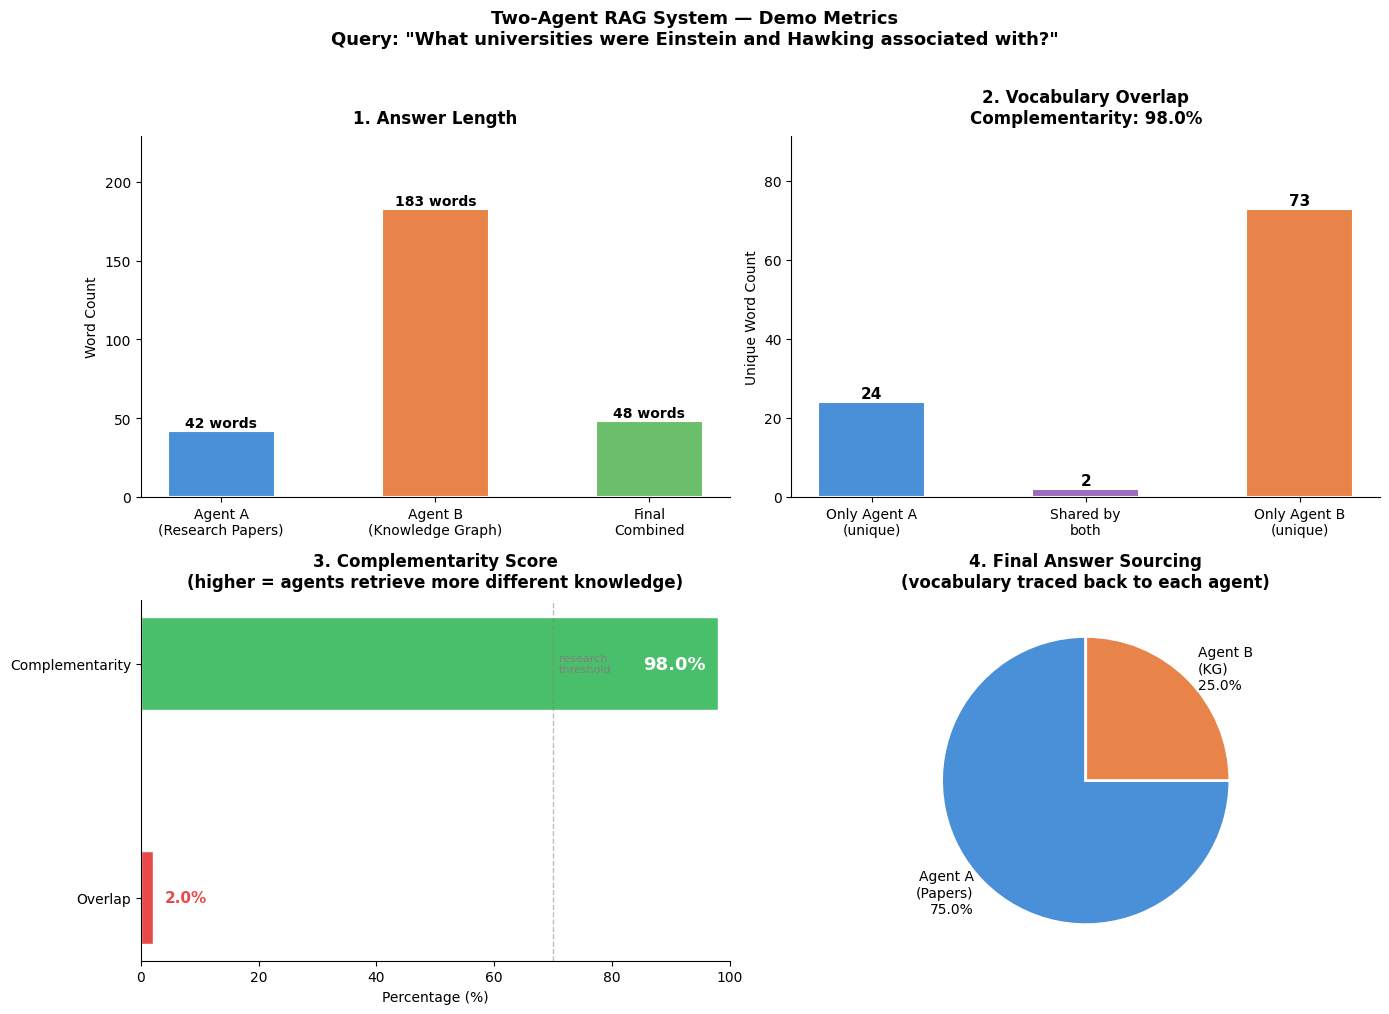

Chart saved as metrics.png in your project folder!


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_metrics(query, answer_a, answer_b, final_answer):
    
    # ── recompute all values ──
    len_a = len(answer_a.split())
    len_b = len(answer_b.split())
    len_final = len(final_answer.split())

    stopwords = {"the","a","an","is","in","of","and","to","it","that","was","for","on","are","with","as","by","this","be","or","at","from","its","not","but","have","had","he","she","they","we","i","you"}
    words_a = set(answer_a.lower().split()) - stopwords
    words_b = set(answer_b.lower().split()) - stopwords
    shared = words_a & words_b
    union = words_a | words_b
    overlap_pct = round(len(shared) / len(union) * 100, 1) if union else 0
    complementarity = 100 - overlap_pct
    only_a = len(words_a - words_b)
    only_b = len(words_b - words_a)
    only_both = len(shared)

    hedging_phrases = ["does not contain","don't have","not enough information","cannot answer","no information","context doesn't","not mentioned","not provided","unclear","not explicitly"]
    hedges_a = sum(1 for p in hedging_phrases if p in answer_a.lower())
    hedges_b = sum(1 for p in hedging_phrases if p in answer_b.lower())

    final_words = set(final_answer.lower().split())
    from_a = len(final_words & words_a)
    from_b = len(final_words & words_b)
    total = max(from_a + from_b, 1)
    pct_a = round(from_a / total * 100, 1)
    pct_b = round(from_b / total * 100, 1)

    # ── set up figure with 4 subplots ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'Two-Agent RAG System — Demo Metrics\nQuery: "{query[:60]}..."' if len(query) > 60 else f'Two-Agent RAG System — Demo Metrics\nQuery: "{query}"',
        fontsize=13, fontweight='bold', y=1.01
    )

    colors_agents = ['#4A90D9', '#E8834A']  # blue for A, orange for B

    # ── plot 1: answer length bar chart ──
    ax1 = axes[0, 0]
    bars = ax1.bar(
        ['Agent A\n(Research Papers)', 'Agent B\n(Knowledge Graph)', 'Final\nCombined'],
        [len_a, len_b, len_final],
        color=[colors_agents[0], colors_agents[1], '#6BBF6B'],
        width=0.5, edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, [len_a, len_b, len_final]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val} words', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_title('1. Answer Length', fontweight='bold', pad=10)
    ax1.set_ylabel('Word Count')
    ax1.set_ylim(0, max(len_a, len_b, len_final) * 1.25)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ── plot 2: vocabulary overlap venn-style bar ──
    ax2 = axes[0, 1]
    categories = ['Only Agent A\n(unique)', 'Shared by\nboth', 'Only Agent B\n(unique)']
    values = [only_a, only_both, only_b]
    bar_colors = [colors_agents[0], '#9B6BBF', colors_agents[1]]
    bars2 = ax2.bar(categories, values, color=bar_colors, width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars2, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_title(f'2. Vocabulary Overlap\nComplementarity: {complementarity}%', fontweight='bold', pad=10)
    ax2.set_ylabel('Unique Word Count')
    ax2.set_ylim(0, max(values) * 1.25)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # ── plot 3: complementarity gauge (horizontal bar) ──
    ax3 = axes[1, 0]
    ax3.barh(['Overlap', 'Complementarity'], [overlap_pct, complementarity],
             color=['#E84A4A', '#4ABF6B'], height=0.4, edgecolor='white')
    ax3.set_xlim(0, 100)
    ax3.axvline(x=70, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax3.text(71, 1, 'research\nthreshold', fontsize=8, color='gray', va='center')
    ax3.text(complementarity - 2, 1, f'{complementarity}%',
             ha='right', va='center', fontsize=13, fontweight='bold', color='white')
    ax3.text(overlap_pct - 2 if overlap_pct > 10 else overlap_pct + 2, 0,
             f'{overlap_pct}%', ha='right' if overlap_pct > 10 else 'left',
             va='center', fontsize=11, fontweight='bold',
             color='white' if overlap_pct > 10 else '#E84A4A')
    ax3.set_title('3. Complementarity Score\n(higher = agents retrieve more different knowledge)',
                  fontweight='bold', pad=10)
    ax3.set_xlabel('Percentage (%)')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    # ── plot 4: final answer sourcing pie ──
    ax4 = axes[1, 1]
    wedge_sizes = [pct_a, pct_b]
    wedge_labels = [f'Agent A\n(Papers)\n{pct_a}%', f'Agent B\n(KG)\n{pct_b}%']
    wedge_colors = [colors_agents[0], colors_agents[1]]
    wedges, texts = ax4.pie(
        wedge_sizes,
        labels=wedge_labels,
        colors=wedge_colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for text in texts:
        text.set_fontsize(10)
    ax4.set_title('4. Final Answer Sourcing\n(vocabulary traced back to each agent)',
                  fontweight='bold', pad=10)

    plt.tight_layout()
    plt.savefig('metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved as metrics.png in your project folder!")

# ── run it ──
plot_metrics(query, result["answer_a"], result["answer_b"], result["final_answer"])

RUNNING FULL EVALUATION
This will take ~30 seconds (3 LLM calls + embeddings)

[Metrics] Computing Faithfulness (STS method)...
[Metrics] Embedding 3 answer sentences and 4 context sentences...

[Metrics] Sentence-level faithfulness breakdown:
  ✓ 0.939 — Based on the provided sources, Hawking was associated with U...
  ✓ 0.875 — There is no mention of Einstein being associated with any un...
  ✓ 0.735 — Einstein's place of death is mentioned as Princeton, but it ...

[Metrics] Faithfulness (STS): 0.849
[Metrics] Computing Answer Relevance...
[Metrics] Answer Relevance: 0.818
[Metrics] Computing Context Utilization...
[Metrics] Context Utilization: 0.2
[Metrics] Computing Agent Complementarity...
[Metrics] Agent Complementarity: 0.659
[Metrics] Computing Multi-hop Utility...
[Metrics] Multi-hop Utility: 0.2

SCORES
  faithfulness           0.849  ████████████████
  relevance              0.818  ████████████████
  utilization            0.200  ████
  complementarity        0.659  ██████

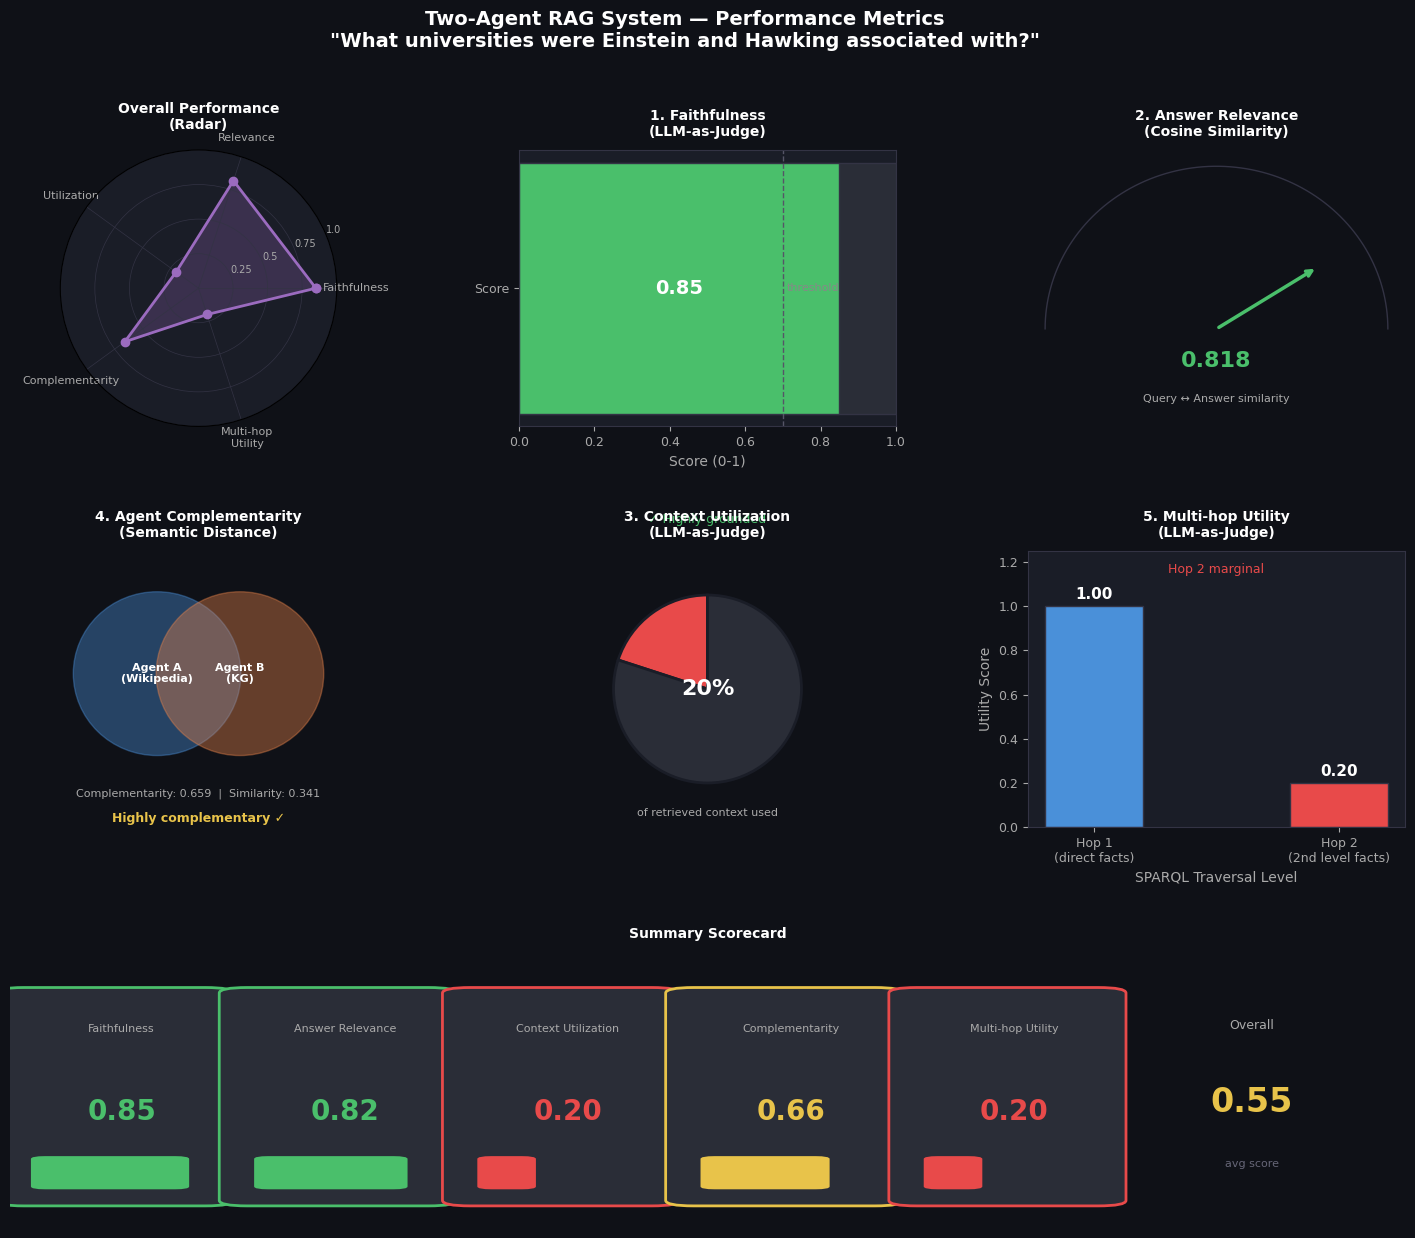


Chart saved as full_metrics.png!


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import time
import re

# ══════════════════════════════════════════════════════════
# METRIC 1 — FAITHFULNESS (LLM as judge)
# measures: are the claims in final answer grounded
# in what agents actually retrieved?
# ══════════════════════════════════════════════════════════

def compute_faithfulness(query, answer_a, answer_b, final_answer):
    """
    Mathematically computes faithfulness using Semantic Textual Similarity.
    
    For every sentence in the final answer, we find the most similar
    sentence in the retrieved context (Agent A + Agent B combined).
    Faithfulness = average of these maximum similarity scores.
    
    No LLM involved — pure cosine similarity using sentence-transformers.
    """
    print("[Metrics] Computing Faithfulness (STS method)...")
    
    # ── step 1: split final answer into sentences ──
    # simple split on punctuation
    final_sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', final_answer) if len(s.strip()) > 20]
    
    if not final_sentences:
        print("[Metrics] No sentences found in final answer")
        return 0.0
    
    # ── step 2: split retrieved context into sentences ──
    # combine both Agent A and Agent B into one context pool
    combined_context = answer_a + " " + answer_b
    context_sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', combined_context) if len(s.strip()) > 20]
    
    if not context_sentences:
        print("[Metrics] No context sentences found")
        return 0.0
    
    # ── step 3: embed everything ──
    # reuse the same embedder already loaded in your notebook
    print(f"[Metrics] Embedding {len(final_sentences)} answer sentences and {len(context_sentences)} context sentences...")
    
    final_embeddings = embedder.encode(final_sentences)
    context_embeddings = embedder.encode(context_sentences)
    
    # ── step 4: for each answer sentence find most similar context sentence ──
    # this is the key step — we're asking:
    # "for each claim I made, what's the closest thing in the retrieved context?"
    similarity_matrix = cosine_similarity(final_embeddings, context_embeddings)
    
    # max similarity for each answer sentence
    max_similarities = similarity_matrix.max(axis=1)
    
    # ── step 5: faithfulness = average of max similarities ──
    faithfulness = float(np.mean(max_similarities))
    
    # ── bonus: show which sentences are well grounded vs not ──
    print(f"\n[Metrics] Sentence-level faithfulness breakdown:")
    for i, (sentence, score) in enumerate(zip(final_sentences, max_similarities)):
        grounded = "✓" if score >= 0.7 else "△" if score >= 0.5 else "✗"
        short = sentence[:60] + "..." if len(sentence) > 60 else sentence
        print(f"  {grounded} {score:.3f} — {short}")
    
    print(f"\n[Metrics] Faithfulness (STS): {faithfulness:.3f}")
    return faithfulness


# ══════════════════════════════════════════════════════════
# METRIC 2 — ANSWER RELEVANCE (cosine similarity)
# measures: does the final answer actually address the query?
# purely mathematical — no LLM needed
# ══════════════════════════════════════════════════════════

def compute_answer_relevance(query, final_answer):
    print("[Metrics] Computing Answer Relevance...")
    
    # embed query and final answer using same embedder
    query_vec = embedder.encode([query])
    answer_vec = embedder.encode([final_answer])
    
    # cosine similarity between 0 and 1
    similarity = cosine_similarity(query_vec, answer_vec)[0][0]
    score = float(similarity)
    
    print(f"[Metrics] Answer Relevance: {score:.3f}")
    return score


# ══════════════════════════════════════════════════════════
# METRIC 3 — CONTEXT UTILIZATION (LLM as judge)
# measures: how much of what was retrieved actually
# made it into the final answer?
# ══════════════════════════════════════════════════════════



# ══════════════════════════════════════════════════════════
# METRIC 4 — AGENT COMPLEMENTARITY (semantic, mathematical)
# measures: how semantically different are Agent A and
# Agent B's answers? High distance = good complementarity
# purely mathematical — no LLM needed
# ══════════════════════════════════════════════════════════

def compute_complementarity(answer_a, answer_b):
    print("[Metrics] Computing Agent Complementarity...")
    
    vec_a = embedder.encode([answer_a])
    vec_b = embedder.encode([answer_b])
    
    # cosine similarity between agents
    similarity = cosine_similarity(vec_a, vec_b)[0][0]
    
    # complementarity = 1 - similarity
    # high complementarity means agents retrieved very different things
    complementarity = 1.0 - float(similarity)
    
    print(f"[Metrics] Agent Complementarity: {complementarity:.3f}")
    return complementarity, float(similarity)


# ══════════════════════════════════════════════════════════
# METRIC 5 — MULTI-HOP UTILITY (LLM as judge)
# measures: did the 2nd hop in SPARQL add anything
# that the 1st hop alone couldn't provide?
# ══════════════════════════════════════════════════════════
def compute_context_utilization(answer_a, answer_b, final_answer):
    print("[Metrics] Computing Context Utilization...")
    
    prompt = f"""Score how much of the retrieved context was used in the final answer.

Retrieved Context A: {answer_a[:400]}

Retrieved Context B: {answer_b[:400]}

Final Answer: {final_answer[:400]}

Instructions:
- Think about what fraction of the retrieved content appears in the final answer
- Return ONLY a single decimal number like 0.3 or 0.7 or 0.5
- Do not write any words, only the number

Score:"""

    try:
        response = llm.invoke(prompt)
        raw = response.content.strip()
        # extract first number found in response
        numbers = re.findall(r'\d+\.?\d*', raw)
        if numbers:
            score = float(numbers[0])
            # if LLM returned a percentage like 70 instead of 0.7
            if score > 1.0:
                score = score / 100.0
            score = max(0.0, min(1.0, score))
        else:
            score = 0.5
    except:
        score = 0.5
    
    print(f"[Metrics] Context Utilization: {score}")
    return score


def compute_multihop_utility(query, answer_b):
    print("[Metrics] Computing Multi-hop Utility...")
    
    # better splitting — look for actual entity blocks in subgraph
    # each block starts with "[ entity name ]"
    blocks = re.split(r'\[.*?\]', answer_b)
    blocks = [b.strip() for b in blocks if b.strip()]
    
    if len(blocks) < 2:
        # not enough blocks to compare hops
        # use first half vs second half as fallback
        lines = answer_b.split("\n")
        mid = len(lines) // 2
        hop1_text = "\n".join(lines[:mid])
        hop2_text = "\n".join(lines[mid:])
    else:
        # first block = main entity (hop 1)
        # remaining blocks = connected entities (hop 2)
        hop1_text = blocks[0]
        hop2_text = "\n".join(blocks[1:])
    
    if not hop2_text.strip():
        print("[Metrics] No hop 2 content found, defaulting to 0.5")
        return 0.5
    
    prompt = f"""Score how much new information Hop 2 added beyond Hop 1 for answering the query.

Query: {query}

Hop 1 (direct facts about main entity):
{hop1_text[:400]}

Hop 2 (facts about connected entities):
{hop2_text[:400]}

Instructions:
- If Hop 2 added important new context not in Hop 1, score closer to 1.0
- If Hop 2 added nothing useful beyond Hop 1, score closer to 0.0
- Return ONLY a single decimal number like 0.3 or 0.7 or 0.8
- Do not write any words, only the number

Score:"""

    try:
        response = llm.invoke(prompt)
        raw = response.content.strip()
        numbers = re.findall(r'\d+\.?\d*', raw)
        if numbers:
            score = float(numbers[0])
            if score > 1.0:
                score = score / 100.0
            score = max(0.0, min(1.0, score))
        else:
            score = 0.5
    except:
        score = 0.5
    
    print(f"[Metrics] Multi-hop Utility: {score}")
    return score
#═════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════

def visualize_all_metrics(query, scores, similarity, answer_a, answer_b, final_answer):
    
    faithfulness = scores["faithfulness"]
    relevance = scores["relevance"]
    utilization = scores["utilization"]
    complementarity = scores["complementarity"]
    multihop = scores["multihop"]

    # ── color scheme ──
    color_a = "#4A90D9"       # blue — Agent A
    color_b = "#E8834A"       # orange — Agent B
    color_good = "#4ABF6B"    # green — good scores
    color_warn = "#E8C34A"    # yellow — medium scores
    color_bad = "#E84A4A"     # red — low scores
    color_purple = "#9B6BBF"  # purple — combined

    def score_color(s):
        if s >= 0.7: return color_good
        elif s >= 0.4: return color_warn
        else: return color_bad

    # ── set up figure ──
    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor('#0F1117')
    
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    title_query = query if len(query) <= 60 else query[:60] + "..."
    fig.suptitle(
        f'Two-Agent RAG System — Performance Metrics\n"{title_query}"',
        fontsize=14, fontweight='bold', color='white', y=0.98
    )

    # ── helper: style axes ──
    def style_ax(ax, title):
        ax.set_facecolor('#1A1D27')
        ax.tick_params(colors='#AAAAAA', labelsize=9)
        ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=10)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')

    # ══ PLOT 1: Radar Chart — all 5 metrics overview ══
    ax1 = fig.add_subplot(gs[0, 0], projection='polar')
    ax1.set_facecolor('#1A1D27')
    
    metrics_names = ['Faithfulness', 'Relevance', 'Utilization', 
                     'Complementarity', 'Multi-hop\nUtility']
    metrics_vals = [faithfulness, relevance, utilization, 
                    complementarity, multihop]
    
    N = len(metrics_names)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # close the polygon
    values = metrics_vals + metrics_vals[:1]
    
    ax1.plot(angles, values, 'o-', linewidth=2, color=color_purple)
    ax1.fill(angles, values, alpha=0.25, color=color_purple)
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(metrics_names, color='white', fontsize=8)
    ax1.set_ylim(0, 1)
    ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax1.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], 
                         color='#888888', fontsize=7)
    ax1.grid(color='#333344', linewidth=0.5)
    ax1.set_title('Overall Performance\n(Radar)', color='white', 
                  fontsize=10, fontweight='bold', pad=15)
    ax1.tick_params(colors='#AAAAAA')

    # ══ PLOT 2: Faithfulness gauge bar ══
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2, '1. Faithfulness\n(LLM-as-Judge)')
    
    ax2.barh(['Score'], [faithfulness], color=score_color(faithfulness), 
             height=0.4, edgecolor='#333344')
    ax2.barh(['Score'], [1.0], color='#2A2D37', height=0.4, 
             edgecolor='#333344', zorder=0)
    ax2.set_xlim(0, 1)
    ax2.axvline(x=0.7, color='#555566', linestyle='--', linewidth=1)
    ax2.text(0.71, 0, 'threshold', color='#888888', fontsize=8, va='center')
    ax2.text(faithfulness / 2, 0, f'{faithfulness:.2f}', 
             ha='center', va='center', fontsize=14, 
             fontweight='bold', color='white')
    ax2.set_xlabel('Score (0-1)', color='#AAAAAA')
    
    interpretation = "✓ Highly grounded" if faithfulness >= 0.7 else "△ Partially grounded" if faithfulness >= 0.4 else "✗ Low grounding"
    ax2.text(0.5, -0.35, interpretation, transform=ax2.transAxes,
             ha='center', color=score_color(faithfulness), fontsize=9)

    # ══ PLOT 3: Answer Relevance ══
    ax3 = fig.add_subplot(gs[0, 2])
    style_ax(ax3, '2. Answer Relevance\n(Cosine Similarity)')
    
    theta = np.linspace(0, np.pi, 100)
    ax3.plot(np.cos(theta), np.sin(theta), color='#333344', linewidth=1)
    
    angle = np.pi * (1 - relevance)
    ax3.annotate('', xy=(np.cos(angle) * 0.7, np.sin(angle) * 0.7),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=score_color(relevance), 
                               lw=2.5))
    ax3.text(0, -0.2, f'{relevance:.3f}', ha='center', va='center',
             fontsize=16, fontweight='bold', color=score_color(relevance))
    ax3.text(0, -0.45, 'Query ↔ Answer similarity', ha='center',
             color='#AAAAAA', fontsize=8)
    ax3.set_xlim(-1.1, 1.1)
    ax3.set_ylim(-0.6, 1.1)
    ax3.axis('off')

    # ══ PLOT 4: Agent Complementarity — semantic distance ══
    ax4 = fig.add_subplot(gs[1, 0])
    style_ax(ax4, '4. Agent Complementarity\n(Semantic Distance)')
    
    # draw two circles showing overlap
    from matplotlib.patches import Circle
    overlap = 1 - complementarity
    offset = complementarity * 1.2
    
    circle_a = Circle((-offset/2, 0), 0.8, alpha=0.4, color=color_a, 
                      label='Agent A')
    circle_b = Circle((offset/2, 0), 0.8, alpha=0.4, color=color_b, 
                      label='Agent B')
    ax4.add_patch(circle_a)
    ax4.add_patch(circle_b)
    
    ax4.text(-offset/2, 0, 'Agent A\n(Wikipedia)', ha='center', 
             va='center', color='white', fontsize=8, fontweight='bold')
    ax4.text(offset/2, 0, 'Agent B\n(KG)', ha='center', 
             va='center', color='white', fontsize=8, fontweight='bold')
    ax4.text(0, -1.2, f'Complementarity: {complementarity:.3f}  |  Similarity: {similarity:.3f}',
             ha='center', color='#AAAAAA', fontsize=8)
    
    ax4.set_xlim(-1.8, 1.8)
    ax4.set_ylim(-1.5, 1.2)
    ax4.axis('off')
    
    verdict = "Highly complementary ✓" if complementarity > 0.6 else "Moderately complementary" if complementarity > 0.3 else "Too similar"
    ax4.text(0, -1.45, verdict, ha='center', 
             color=score_color(complementarity), fontsize=9, fontweight='bold')

    # ══ PLOT 5: Context Utilization ══
    ax5 = fig.add_subplot(gs[1, 1])
    style_ax(ax5, '3. Context Utilization\n(LLM-as-Judge)')
    
    used = utilization
    unused = 1.0 - utilization
    wedges, texts = ax5.pie(
        [used, unused],
        colors=[score_color(utilization), '#2A2D37'],
        startangle=90,
        wedgeprops={'edgecolor': '#1A1D27', 'linewidth': 2},
        radius=0.85
    )
    ax5.text(0, 0, f'{utilization:.0%}', ha='center', va='center',
             fontsize=16, fontweight='bold', color='white')
    ax5.text(0, -1.15, 'of retrieved context used', ha='center',
             color='#AAAAAA', fontsize=8)

    # ══ PLOT 6: Multi-hop Utility ══
    ax6 = fig.add_subplot(gs[1, 2])
    style_ax(ax6, '5. Multi-hop Utility\n(LLM-as-Judge)')
    
    hops = ['Hop 1\n(direct facts)', 'Hop 2\n(2nd level facts)']
    hop_vals = [1.0, multihop]  # hop 1 always contributes, hop 2 is measured
    bars = ax6.bar(hops, hop_vals, color=[color_a, score_color(multihop)],
                   width=0.4, edgecolor='#333344')
    
    for bar, val in zip(bars, hop_vals):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', 
                 color='white', fontsize=11, fontweight='bold')
    
    ax6.set_ylim(0, 1.25)
    ax6.set_ylabel('Utility Score', color='#AAAAAA')
    ax6.set_xlabel('SPARQL Traversal Level', color='#AAAAAA')
    
    utility_text = "Hop 2 adds value ✓" if multihop >= 0.5 else "Hop 2 marginal"
    ax6.text(0.5, 0.92, utility_text, transform=ax6.transAxes,
             ha='center', color=score_color(multihop), fontsize=9)

    # ══ PLOT 7: Summary scorecard — bottom full width ══
    ax7 = fig.add_subplot(gs[2, :])
    style_ax(ax7, 'Summary Scorecard')
    ax7.axis('off')
    
    all_scores = {
        'Faithfulness': faithfulness,
        'Answer Relevance': relevance,
        'Context Utilization': utilization,
        'Complementarity': complementarity,
        'Multi-hop Utility': multihop
    }
    overall = np.mean(list(all_scores.values()))
    
    # draw score boxes
    x_positions = [0.08, 0.24, 0.40, 0.56, 0.72]
    for i, (name, score) in enumerate(all_scores.items()):
        x = x_positions[i]
        color = score_color(score)
        
        fancy_box = mpatches.FancyBboxPatch(
            (x - 0.07, 0.1), 0.13, 0.75,
            boxstyle="round,pad=0.02",
            facecolor='#2A2D37', edgecolor=color, linewidth=2,
            transform=ax7.transAxes
        )
        ax7.add_patch(fancy_box)
        
        ax7.text(x, 0.72, name, transform=ax7.transAxes,
                ha='center', va='center', color='#AAAAAA', fontsize=8)
        ax7.text(x, 0.42, f'{score:.2f}', transform=ax7.transAxes,
                ha='center', va='center', color=color, 
                fontsize=20, fontweight='bold')
        
        bar_width = 0.11
        ax7.add_patch(mpatches.FancyBboxPatch(
            (x - bar_width/2, 0.15), bar_width * score, 0.1,
            boxstyle="round,pad=0.01",
            facecolor=color, edgecolor='none',
            transform=ax7.transAxes
        ))
    
    # overall score
    ax7.text(0.89, 0.72, 'Overall', transform=ax7.transAxes,
            ha='center', color='#AAAAAA', fontsize=9)
    ax7.text(0.89, 0.42, f'{overall:.2f}', transform=ax7.transAxes,
            ha='center', color=score_color(overall), 
            fontsize=24, fontweight='bold')
    ax7.text(0.89, 0.22, 'avg score', transform=ax7.transAxes,
            ha='center', color='#666677', fontsize=8)

    plt.savefig('full_metrics.png', dpi=150, bbox_inches='tight',
                facecolor='#0F1117')
    plt.show()
    print("\nChart saved as full_metrics.png!")


# ══════════════════════════════════════════════════════════
# MAIN — RUN ALL METRICS
# ══════════════════════════════════════════════════════════

def run_full_evaluation(query, result):
    
    answer_a = result["answer_a"]
    answer_b = result["answer_b"]
    final_answer = result["final_answer"]
    
    print("=" * 60)
    print("RUNNING FULL EVALUATION")
    print("=" * 60)
    print("This will take ~30 seconds (3 LLM calls + embeddings)\n")
    
    # compute all 5 metrics
    faithfulness = compute_faithfulness(query, answer_a, answer_b, final_answer)
    time.sleep(1)
    
    relevance = compute_answer_relevance(query, final_answer)
    
    utilization = compute_context_utilization(answer_a, answer_b, final_answer)
    time.sleep(1)
    
    complementarity, similarity = compute_complementarity(answer_a, answer_b)
    
    multihop = compute_multihop_utility(query, answer_b)
    time.sleep(1)
    
    scores = {
        "faithfulness": faithfulness,
        "relevance": relevance,
        "utilization": utilization,
        "complementarity": complementarity,
        "multihop": multihop
    }
    
    # print summary
    print("\n" + "=" * 60)
    print("SCORES")
    print("=" * 60)
    for name, score in scores.items():
        bar = "█" * int(score * 20)
        print(f"  {name:<22} {score:.3f}  {bar}")
    print(f"\n  {'Overall':<22} {np.mean(list(scores.values())):.3f}")
    
    # visualize
    visualize_all_metrics(
        query, scores, similarity,
        answer_a, answer_b, final_answer
    )
    
    return scores

# ── run it ──
scores = run_full_evaluation(query, result)

In [16]:
# ── debug cell — run this to see raw LLM responses ──

# test context utilization prompt
prompt_util = f"""Score how much of the retrieved context was used in the final answer.

Retrieved Context A: {result['answer_a'][:400]}

Retrieved Context B: {result['answer_b'][:400]}

Final Answer: {result['final_answer'][:400]}

Instructions:
- Return ONLY a single decimal number like 0.3 or 0.7 or 0.5
- Do not write any words, only the number

Score:"""

response_util = llm.invoke(prompt_util)
print("RAW UTILIZATION RESPONSE:")
print(repr(response_util.content))
print("---")

# test multihop prompt
prompt_hop = f"""Score how much new information Hop 2 added beyond Hop 1.

Query: {query}

Hop 1: Some direct facts about the entity.
Hop 2: Some facts about connected entities.

Return ONLY a decimal number between 0 and 1.

Score:"""

response_hop = llm.invoke(prompt_hop)
print("RAW MULTIHOP RESPONSE:")
print(repr(response_hop.content))
print("---")

# also print what answer_b looks like
print("ANSWER B FIRST 300 CHARS:")
print(repr(result['answer_b'][:300]))

RAW UTILIZATION RESPONSE:
'0.6'
---
RAW MULTIHOP RESPONSE:
'0.8'
---
ANSWER B FIRST 300 CHARS:
'KNOWLEDGE GRAPH SUBGRAPH (structured facts retrieved via SPARQL)\n\nTotal triples retrieved: 30\n\n[ Albert Einstein ]\n  occupation → pacifist\n  occupation → philosopher of science\n  occupation → theoretical physicist\n  mother → Pauline Koch\n  place of birth → Ulm\n  occupation → science writer\n  occupat'


In [17]:
# pip freeze > requirements.txt